In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [3]:
loan_df = pd.read_csv(
    r"C:\Users\henry\OneDrive\Desktop\LendingClub-Data-Pipeline\data\processed\clean_loan.csv"
)

loan_df.head()  




,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,purpose,loan_status,emp_title,emp_length,home_ownership,annual_inc,verification_status,application_type,addr_state,zip_code,grade,sub_grade,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,acc_now_delinq,out_prncp,total_pymnt,total_rec_prncp,total_rec_int,recoveries,last_pymnt_d,last_pymnt_amnt,last_credit_pull_d,issue_d,total_rev_hi_lim
0,2500,2500,2500.0,36 months,13.56,84.92,debt_consolidation,Current,Chef,10+ years,RENT,55000.0,Not Verified,Individual,NY,109xx,C,C1,18.24,0.0,Apr-2001,1.0,9.0,1.0,4341,10.3,34.0,1970-01-01,2386.02,167.02,113.98,53.04,0.0,2019-02-01,84.92,2019-02-01,2018-12-01,42000.0
1,30000,30000,30000.0,60 months,18.94,777.23,debt_consolidation,Current,Postmaster,10+ years,MORTGAGE,90000.0,Source Verified,Individual,LA,713xx,D,D2,26.52,0.0,Jun-1987,0.0,13.0,1.0,12315,24.2,44.0,1970-01-01,29387.75,1507.11,612.25,894.86,0.0,2019-02-01,777.23,2019-02-01,2018-12-01,50800.0
2,5000,5000,5000.0,36 months,17.97,180.69,debt_consolidation,Current,Administrative,6 years,MORTGAGE,59280.0,Source Verified,Individual,MI,490xx,D,D1,10.51,0.0,Apr-2011,0.0,8.0,0.0,4599,19.1,13.0,1970-01-01,4787.21,353.89,212.79,141.10,0.0,2019-02-01,180.69,2019-02-01,2018-12-01,24100.0
3,4000,4000,4000.0,36 months,18.94,146.51,debt_consolidation,Current,IT Supervisor,10+ years,MORTGAGE,92000.0,Source Verified,Individual,WA,985xx,D,D2,16.74,0.0,Feb-2006,0.0,10.0,0.0,5468,78.1,13.0,1970-01-01,3831.93,286.71,168.07,118.64,0.0,2019-02-01,146.51,2019-02-01,2018-12-01,7000.0
4,30000,30000,30000.0,60 months,16.14,731.78,debt_consolidation,Current,Mechanic,10+ years,MORTGAGE,57250.0,Not Verified,Individual,MD,212xx,C,C4,26.35,0.0,Dec-2000,0.0,12.0,0.0,829,3.6,26.0,1970-01-01,29339.02,1423.21,660.98,762.23,0.0,2019-02-01,731.78,2019-02-01,2018-12-01,23100.0


In [4]:
print("Rows :", loan_df.shape[0])
print("Columns :", loan_df.shape[1])

loan_df.info()

Rows : 2260668
Columns : 38
<class 'pandas.DataFrame'>
RangeIndex: 2260668 entries, 0 to 2260667
Data columns (total 38 columns):
 #   Column               Dtype  
---  ------               -----  
 0   loan_amnt            int64  
 1   funded_amnt          int64  
 2   funded_amnt_inv      float64
 3   term                 str    
 4   int_rate             float64
 5   installment          float64
 6   purpose              str    
 7   loan_status          str    
 8   emp_title            str    
 9   emp_length           str    
 10  home_ownership       str    
 11  annual_inc           float64
 12  verification_status  str    
 13  application_type     str    
 14  addr_state           str    
 15  zip_code             str    
 16  grade                str    
 17  sub_grade            str    
 18  dti                  float64
 19  delinq_2yrs          float64
 20  earliest_cr_line     str    
 21  inq_last_6mths       float64
 22  open_acc             float64
 23  pub_rec        

In [11]:
loan_df.describe().T

,count,mean,std,min,25%,50%,75%,max
loan_amnt,2260668.0,15046.931228,9190.245488,500.00,8000.00,12900.000000,20000.000000,4.000000e+04
funded_amnt,2260668.0,15041.664057,9188.413022,500.00,8000.00,12875.000000,20000.000000,4.000000e+04
funded_amnt_inv,2260668.0,15023.437624,9192.331807,0.00,8000.00,12800.000000,20000.000000,4.000000e+04
int_rate,2260668.0,13.092913,4.832114,5.31,9.49,12.620000,15.990000,3.099000e+01
installment,2260668.0,445.807646,267.173725,4.93,251.65,377.990000,593.320000,1.719830e+03
annual_inc,2260668.0,77992.405698,112696.101198,0.00,46000.00,65000.000000,93000.000000,1.100000e+08
dti,2260668.0,18.823452,14.177986,-1.00,11.90,17.840000,24.480000,9.990000e+02
delinq_2yrs,2260668.0,0.306875,0.867225,0.00,0.00,0.000000,0.000000,5.800000e+01
inq_last_6mths,2260668.0,0.576828,0.885960,0.00,0.00,0.000000,1.000000,3.300000e+01
open_acc,2260668.0,11.612394,5.640826,0.00,8.00,11.000000,14.000000,1.010000e+02


In [5]:
missing = (
    loan_df.isnull()
    .sum()
    .sort_values(ascending=False)
)

missing = missing[missing > 0]

missing

last_pymnt_d          2426
last_credit_pull_d      73
acc_now_delinq          29
dtype: int64

In [6]:
total_loan = loan_df["loan_amnt"].sum()

print(f"Total Loan Amount : ${total_loan:,.2f}")

Total Loan Amount : $34,016,115,925.00


In [7]:
avg_loan = loan_df["loan_amnt"].mean()

print(avg_loan)

15046.931227849467


In [8]:
loan_df.shape[0]

2260668

In [9]:
loan_df["int_rate"].mean()

np.float64(13.092912944315573)

In [10]:
loan_df["recoveries"].sum()

np.float64(307618132.18289286)

In [11]:
loan_df["out_prncp"].sum()

np.float64(10051592040.29)

In [12]:
loan_df["loan_status"].value_counts()

loan_status
Fully Paid                                             1041952
Current                                                 919695
Charged Off                                             261655
Late (31-120 days)                                       21897
In Grace Period                                           8952
Late (16-30 days)                                         3737
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     31
Name: count, dtype: int64

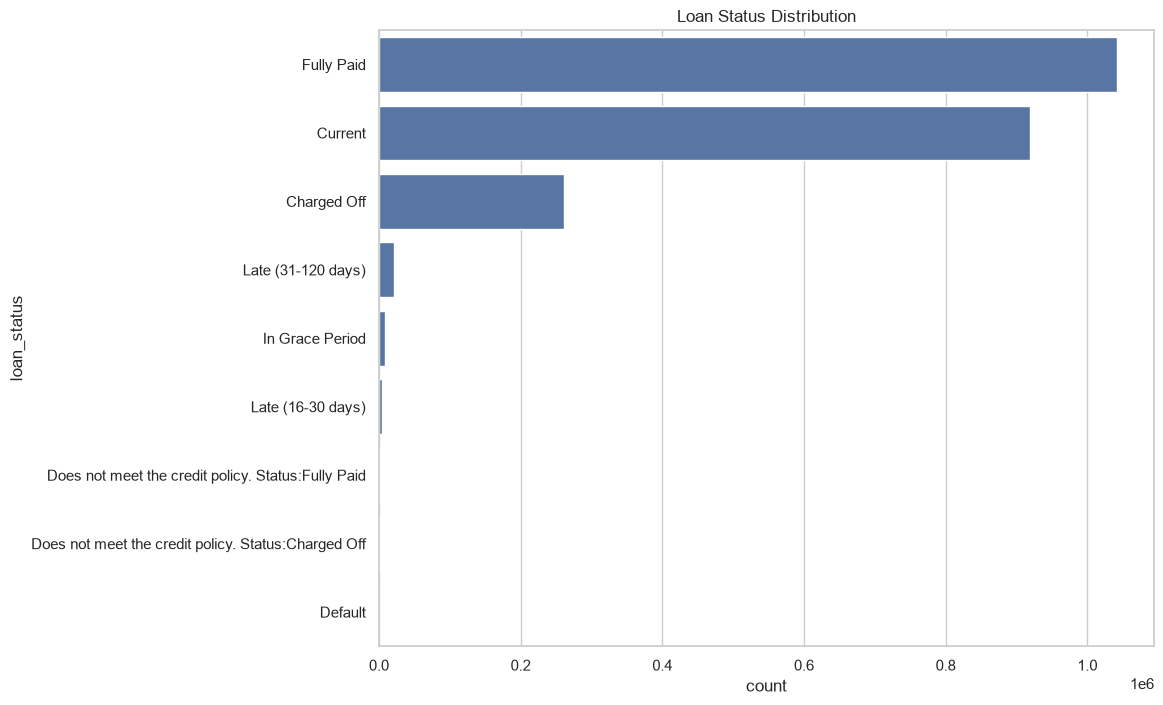

In [44]:
plt.figure(figsize=(10,8))

sns.countplot(
    data=loan_df,
    y="loan_status",
    order=loan_df.loan_status.value_counts().index
)

plt.title("Loan Status Distribution")

plt.show()

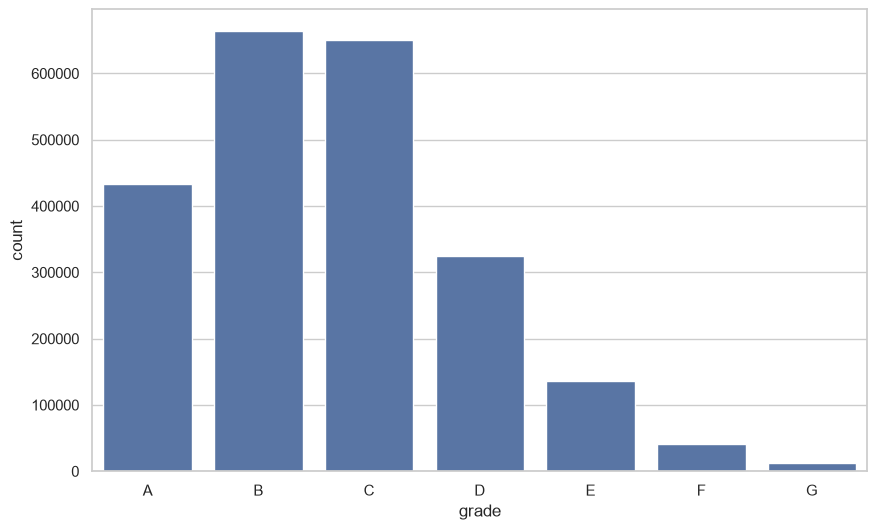

In [50]:
# Grade Analysis


loan_df["grade"].value_counts()


plt.figure(figsize=(10,6))

sns.countplot(
    data=loan_df,
    x="grade",
    order=sorted(loan_df.grade.unique())
)

plt.show()

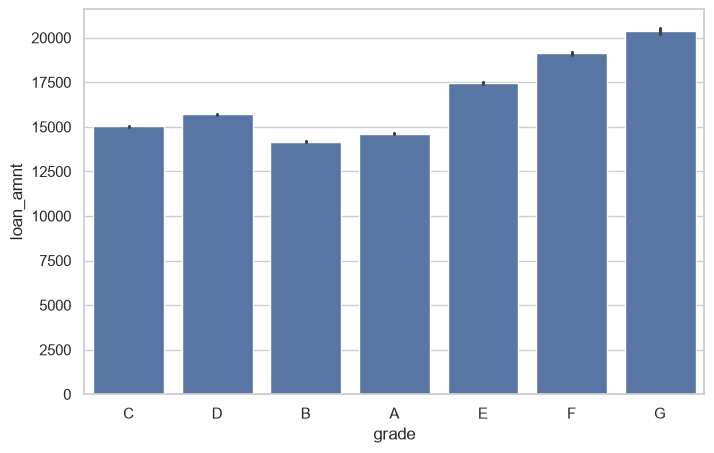

In [51]:
loan_df.groupby("grade")["loan_amnt"].mean().sort_index()


plt.figure(figsize=(10,6))

sns.barplot(
    data=loan_df,
    x="grade",
    y="loan_amnt",
    estimator=np.mean   
)

plt.show()



<Axes: xlabel='loan_amnt', ylabel='Count'>

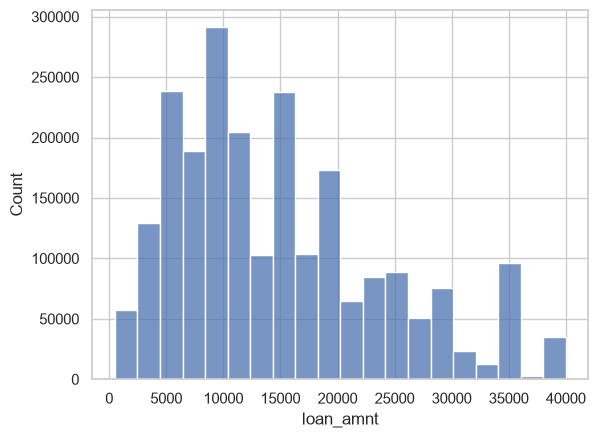

In [52]:
sns.histplot(
    loan_df["loan_amnt"],
    bins=20
)

<Axes: xlabel='int_rate', ylabel='Count'>

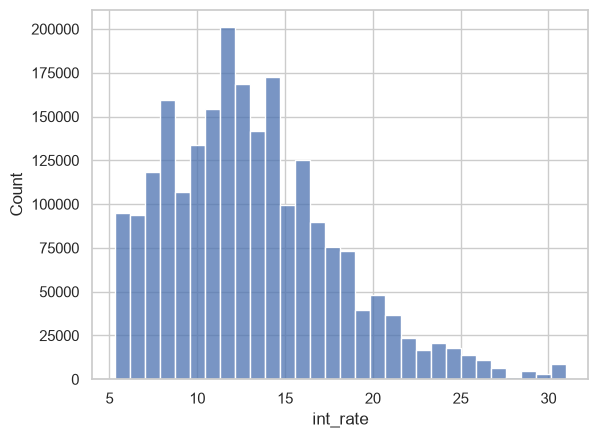

In [53]:
sns.histplot(
    loan_df["int_rate"],
    bins=30
)

<Axes: xlabel='grade', ylabel='count'>

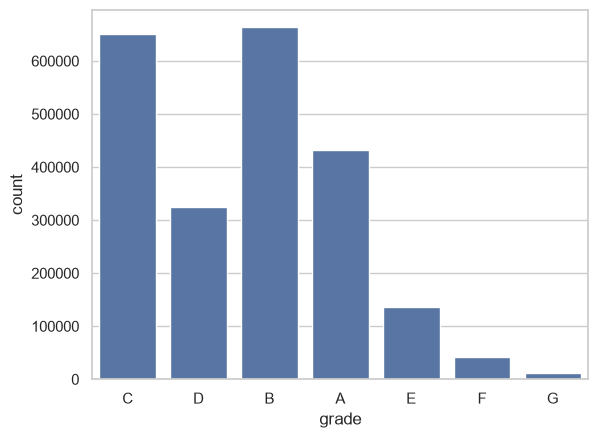

In [54]:
sns.countplot(
    data=loan_df,
    x="grade"
)

In [55]:
loan_df.groupby("grade")["int_rate"].mean().sort_values(ascending=False)


grade
G    28.074255
F    25.454203
E    21.829848
D    18.143304
C    14.143793
B    10.675819
A     7.084558
Name: int_rate, dtype: float64

<Axes: xlabel='grade', ylabel='int_rate'>

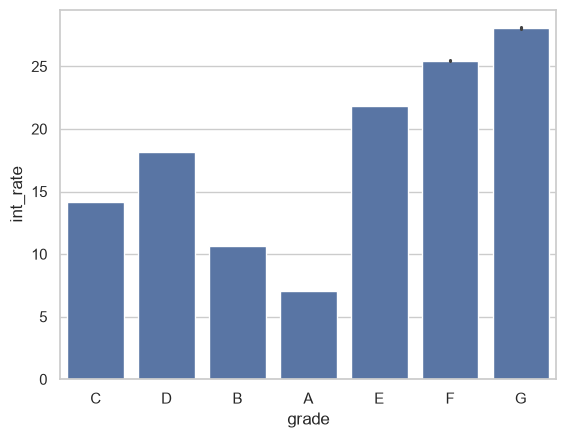

In [56]:
sns.barplot(
    data=loan_df,
    x="grade",
    y="int_rate",
    estimator=np.mean
)

<Axes: xlabel='count', ylabel='purpose'>

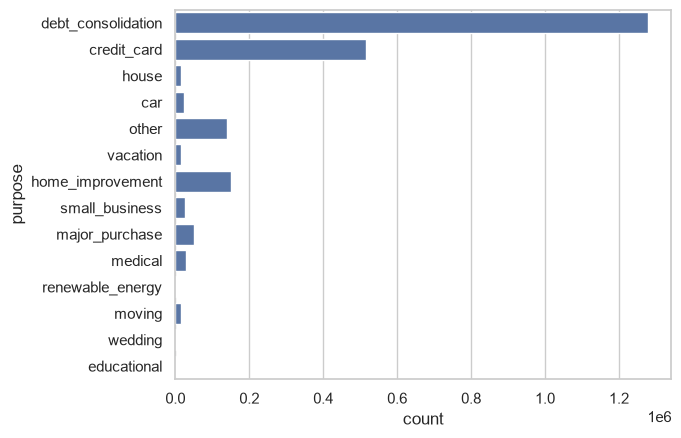

In [57]:
sns.countplot(
    data=loan_df,
    y="purpose"
)

In [39]:
loan_df["addr_state"].value_counts().head(10).sort_values(ascending=False)

addr_state
CA    314533
NY    186389
TX    186335
FL    161991
IL     91173
NJ     83132
PA     76939
OH     75132
GA     74196
VA     62954
Name: count, dtype: int64

<Axes: xlabel='home_ownership', ylabel='count'>

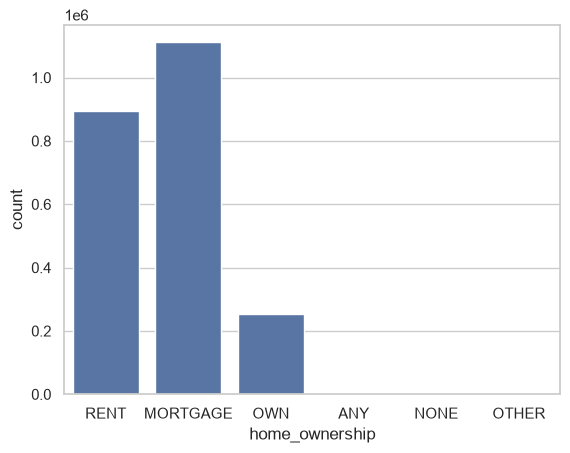

In [ ]:
sns.countplot(
    data=loan_df,
    x="home_ownership"
)

<Axes: xlabel='emp_length', ylabel='loan_amnt'>

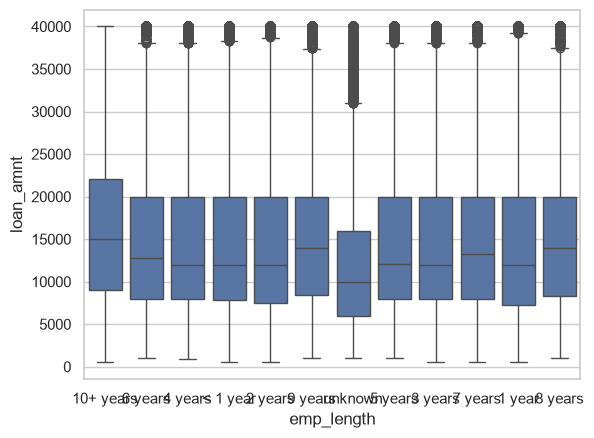

In [58]:
sns.boxplot(
    data= loan_df,
    x="emp_length",
    y="loan_amnt"
)

<Axes: xlabel='annual_inc', ylabel='Count'>

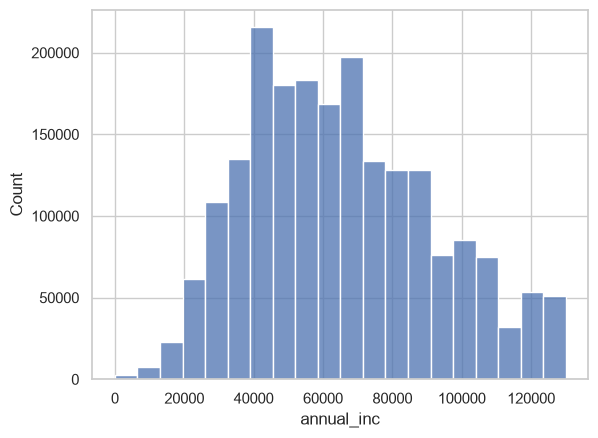

In [71]:
df_annual_inc = loan_df[loan_df["annual_inc"] <= loan_df["annual_inc"].quantile(0.90)]
sns.histplot(
    x = df_annual_inc["annual_inc"],
    bins=20
)

In [67]:
loan_df["annual_inc"].describe()

count    2.260668e+06
mean     7.799241e+04
std      1.126961e+05
min      0.000000e+00
25%      4.600000e+04
50%      6.500000e+04
75%      9.300000e+04
max      1.100000e+08
Name: annual_inc, dtype: float64

In [68]:
loan_df["annual_inc"].nlargest(10)          

1519700    110000000.0
1369278     61000000.0
1458483     10999200.0
372715       9930475.0
61127        9757200.0
675605       9573072.0
714651       9550000.0
1381011      9522972.0
1160644      9500000.0
1351377      9300086.0
Name: annual_inc, dtype: float64

<Axes: xlabel='dti', ylabel='Count'>

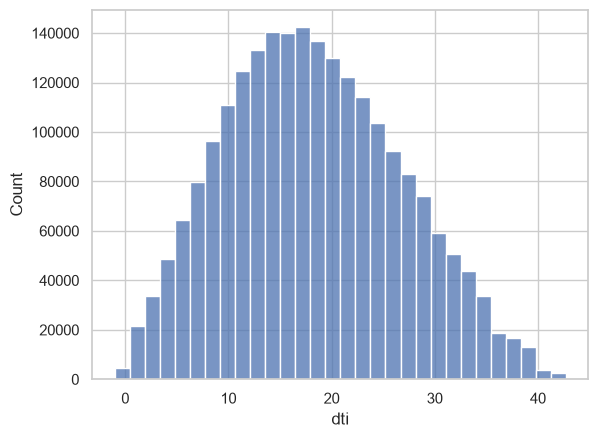

In [83]:




df_dti = loan_df[loan_df["dti"] <= loan_df["dti"].quantile(0.99)]

sns.histplot(
    df_dti["dti"],
    bins=30

)

<Axes: xlabel='loan_amnt', ylabel='int_rate'>

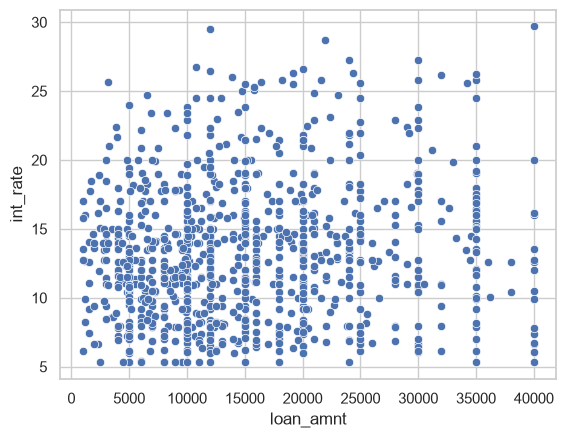

In [88]:
sample = loan_df.sample(1000, random_state=42)

sns.scatterplot(
    data=sample,
    x="loan_amnt",
    y="int_rate"
)

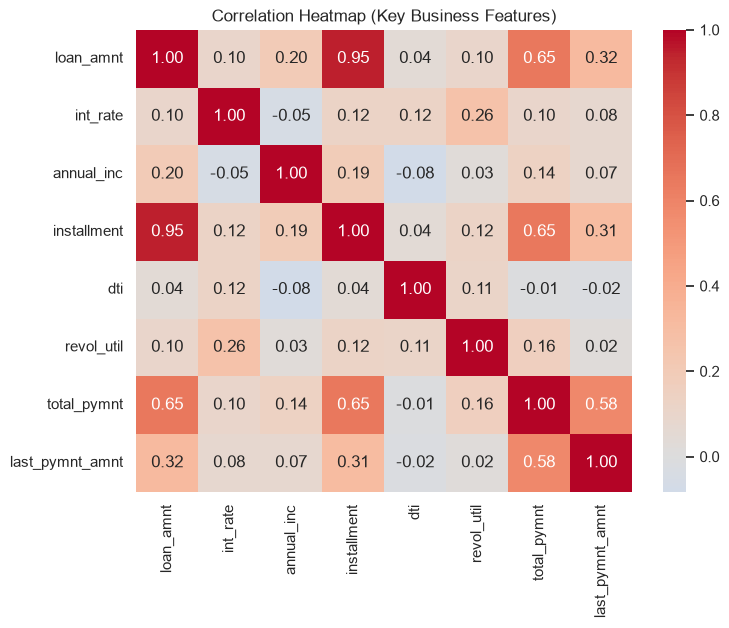

In [91]:
cols = [
    "loan_amnt",
    "int_rate",
    "annual_inc",
    "installment",
    "dti",
    "revol_util",
    "total_pymnt",
    "last_pymnt_amnt"
]

corr = loan_df[cols].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap (Key Business Features)")
plt.show()

In [ ]:
# Exploratory Data Analysis (EDA) Report
# Project Overview

# The objective of this Exploratory Data Analysis (EDA) is to understand the characteristics of the Lending Club loan portfolio from a business perspective. The analysis focuses on borrower behavior, loan distribution, credit risk, repayment patterns, and relationships among important lending variables. The insights obtained from this analysis can support business decision-making and serve as the foundation for feature engineering, ETL development, dashboards, and predictive analytics.

# 1. Portfolio Overview
# Key Metrics
# Metric	Value
# Total Loans	2,260,668
# Total Loan Amount	$34.02 Billion
# Average Loan Amount	$15,046.93
# Average Interest Rate	13.09%
# Outstanding Principal	$10.05 Billion
# Total Recoveries	$307.62 Million
# Observation
# The dataset contains over 2.26 million loan records.
# Total loans issued exceed $34 billion, indicating a large lending portfolio.
# The average loan size is approximately $15,000.
# Business Insight

# The company operates a large and diversified lending portfolio. Effective credit risk management and continuous monitoring are essential because even a small increase in default rates can have a significant financial impact.

# Recommendation
# Monitor portfolio KPIs such as Total Loan Amount, Default Rate, Recovery Rate, and Outstanding Principal.
# Continuously evaluate portfolio quality using repayment performance metrics.
# 2. Loan Status Analysis
# Observation
# Fully Paid loans represent the largest portion of the portfolio.
# Current loans account for another significant share.
# Charged Off loans are the third-largest category.
# Late-payment and Default categories represent only a small percentage.
# Business Insight

# A large number of Fully Paid loans indicates healthy repayment performance. However, the substantial number of Charged Off loans highlights the importance of credit risk management.

# Recommendation
# Analyze borrower characteristics associated with Charged Off loans.
# Develop early-warning systems for identifying potential defaults.
# 3. Loan Grade Analysis
# Observation
# Grades B and C contain the highest number of borrowers.
# Grade A also represents a significant share.
# Loan volume decreases progressively from Grade D to Grade G.
# Business Insight

# The portfolio primarily consists of borrowers with moderate credit quality, maintaining a balance between portfolio growth and credit risk.

# Recommendation

# Maintain a diversified portfolio while limiting excessive exposure to lower credit grades.

# 4. Average Loan Amount by Grade
# Observation
# Average loan amounts generally increase from Grade A to Grade G.
# Grade G borrowers receive the highest average loan amount.
# Business Insight

# Riskier borrowers tend to receive larger loans, increasing the lender's financial exposure in the event of default.

# Recommendation

# Apply stricter affordability checks and underwriting policies for large loans issued to lower-grade borrowers.

# 5. Loan Amount Distribution
# Observation
# Most loans fall between $5,000 and $20,000.
# High-value loans above $30,000 are relatively uncommon.
# Business Insight

# The portfolio is primarily focused on medium-sized personal loans.

# Recommendation

# Continue optimizing products for the medium-loan segment while monitoring high-value loan performance.

# 6. Interest Rate Analysis
# Observation
# Interest rates range approximately from 5% to 31%.
# Most loans are issued between 8% and 16%.
# Business Insight

# The portfolio is concentrated around moderate-risk borrowers.

# Higher interest rate loans represent higher-risk customers.

# Recommendation

# Regularly monitor the performance of high-interest loans to balance profitability with credit risk.

# 7. Interest Rate by Grade
# Observation

# Average interest rate increases consistently across grades.

# Grade	Avg Interest Rate
# A	7.08%
# B	10.68%
# C	14.14%
# D	18.14%
# E	21.83%
# F	25.45%
# G	28.07%
# Business Insight

# The company follows a clear risk-based pricing strategy, charging higher interest rates to borrowers with lower credit quality.

# Recommendation

# Regularly validate pricing policies to ensure they adequately compensate for credit risk.

# 8. Loan Purpose Analysis
# Observation
# Debt Consolidation dominates the portfolio.
# Credit Card refinancing is the second-largest category.
# Home Improvement contributes a moderate share.
# Other categories have relatively low loan volume.
# Business Insight

# Borrowers primarily seek loans for managing existing debt rather than financing new purchases.

# Recommendation

# Develop specialized lending products for Debt Consolidation customers and evaluate repayment performance across loan purposes.

# 9. State-wise Analysis
# Top States
# California
# New York
# Texas
# Florida
# Illinois
# Observation

# Loan demand is concentrated in a few large states.

# Business Insight

# These states represent the company's primary lending markets.

# Regional economic conditions may significantly affect portfolio performance.

# Recommendation

# Create region-specific lending and marketing strategies while monitoring state-level default trends.

# 10. Annual Income Analysis
# Observation
# Mean annual income: $77,992
# Median annual income: $65,000
# Maximum income: $110 Million

# The income distribution is right-skewed with several extreme outliers.

# Business Insight

# Most borrowers have moderate incomes, while a small number of extremely high-income borrowers distort the distribution.

# Recommendation
# Use median and IQR alongside the mean.
# Investigate extreme income values before model development.
# Consider log transformation during feature engineering.
# 11. Debt-to-Income (DTI) Analysis
# Observation

# After excluding extreme outliers for visualization, DTI values are concentrated in the lower-to-middle range.

# Most borrowers maintain moderate debt obligations relative to their income.

# Business Insight

# DTI is one of the strongest indicators of repayment capacity.

# Higher DTI borrowers generally represent higher repayment risk.

# Recommendation

# Use DTI as an important feature in credit scoring and predictive models.

# 12. Scatter Plot Analysis (Loan Amount vs Interest Rate)
# Observation

# The scatter plot shows considerable variation in interest rates across loan amounts.

# No strong linear relationship is visible between loan amount and interest rate.

# Borrowers with similar loan amounts can receive substantially different interest rates.

# Business Insight

# Interest rate determination depends on multiple borrower characteristics rather than loan amount alone.

# Recommendation

# Combine loan amount with borrower credit grade, DTI, income, and credit history for more accurate risk assessment.

# 13. Correlation Analysis
# Key Findings
# Loan Amount ↔ Funded Amount → Strong Positive Correlation
# Loan Amount ↔ Installment → Strong Positive Correlation
# Annual Income ↔ Loan Amount → Weak Positive Correlation
# Interest Rate ↔ DTI → Weak Relationship
# Most remaining variables exhibit weak-to-moderate correlations.
# Business Insight

# Strong correlations explain the lending process, while weaker relationships suggest that borrower behavior is influenced by multiple independent factors.

# Recommendation

# Evaluate highly correlated variables during feature engineering to identify redundant information.

# Overall Business Conclusion
# Key Findings
# The lending portfolio exceeds $34 billion across 2.26 million loans.
# Average loan size is approximately $15K.
# Average interest rate is 13.09%.
# Fully Paid loans dominate the portfolio, indicating generally healthy repayment performance.
# Charged Off loans remain a significant credit risk.
# Grades B and C represent the largest borrower segments.
# Interest rates increase consistently from Grade A to Grade G, confirming a risk-based pricing strategy.
# Debt Consolidation is the most common borrowing purpose.
# California, New York, and Texas account for the highest loan volumes.
# Annual income distribution contains significant outliers.
# DTI is an important indicator of borrower repayment capacity.
# Correlation analysis identifies strong relationships between loan amount, funded amount, and installment.
# Business Recommendations
# Strengthen monitoring of Charged Off and high-risk borrowers to reduce future defaults.
# Continue focusing on the Debt Consolidation segment while evaluating repayment performance across loan purposes.
# Optimize state-level marketing and lending strategies for high-volume regions.
# Apply stricter underwriting for larger loans issued to lower credit grades.
# Incorporate DTI, Annual Income, Loan Grade, and Interest Rate into future credit scoring models.
# Investigate income outliers before predictive modeling and apply appropriate transformations where necessary.
# Review highly correlated variables during feature engineering to avoid redundant information in machine learning models.
# Final Summary

# This exploratory data analysis successfully examined the Lending Club loan portfolio from a business perspective. The analysis identified borrower characteristics, lending patterns, repayment behavior, regional demand, credit quality, and financial risk indicators. These findings provide actionable insights for portfolio management, credit risk assessment, and lending strategy. Furthermore, the cleaned dataset and business insights establish a strong foundation for the next phases of the project, including Feature Engineering, ETL Pipeline Development, Data Warehouse Design, KPI Reporting, Power BI Dashboard Creation, and Machine Learning-based Loan Default Prediction.